# **Phase 0: Setup**

### Google Drive Mount

In [2]:
import sys
print(sys.executable)

c:\Users\Student\.conda\envs\gpu_env\python.exe


In [1]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Student\.conda\envs\gpu_env\python.exe
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [4]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4090


In [5]:
!pip install -r requirements.txt

In [6]:
import os
import copy
import random
import warnings
import numpy as np
import pandas as pd
# Image processing
from PIL import Image
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
    random_split
)
import torchvision
from torchvision import transforms
# Model backbones
import timm
# Machine Learning metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Progress bar
from tqdm import tqdm

# Federated Learning
import flwr as fl
print("Environment OK")
print("GPU:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Environment OK
GPU: True
NVIDIA GeForce RTX 4090


### Project Path

In [7]:
import os

PROJECT_PATH = r"C:\SRS(isic_2019)"
print(os.listdir(PROJECT_PATH))

['best_isic_model.pth', 'Dataset', 'federated', 'ISIC_Federated_Main.ipynb', 'requirements.txt']


### Dataset Path

In [8]:
DATASET_PATH = os.path.join(
    PROJECT_PATH,
    "Dataset"
)
print(DATASET_PATH)



C:\SRS(isic_2019)\Dataset


In [9]:
classes = os.listdir(DATASET_PATH)
print(classes)

['AK', 'BCC', 'BKL', 'DF', 'ISIC_2019_Training_GroundTruth.csv', 'MEL', 'NV', 'SCC', 'VASC']


## Dataset Metadata 

In [10]:
import pandas as pd
classes = ['Ak', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

image_paths = []
labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(DATASET_PATH, cls)
    for img in os.listdir(folder):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(folder, img))
            labels.append(label)

df = pd.DataFrame({"image_path": image_paths, "label": labels})
df.head()

,image_path,label
0,C:\SRS(isic_2019)\Dataset\Ak\ISIC_0024468.jpg,0
1,C:\SRS(isic_2019)\Dataset\Ak\ISIC_0024470.jpg,0
2,C:\SRS(isic_2019)\Dataset\Ak\ISIC_0024511.jpg,0
3,C:\SRS(isic_2019)\Dataset\Ak\ISIC_0024646.jpg,0
4,C:\SRS(isic_2019)\Dataset\Ak\ISIC_0024654.jpg,0


In [11]:
df['label'].value_counts()

label
5    12875
4     4522
1     3323
2     2624
0      867
6      628
7      253
3      239
Name: count, dtype: int64

## Train / Validation / Test Split

In [12]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

print(len(train_df), len(val_df), len(test_df))

17731 3800 3800


### Image Transform

In [14]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Augmentation variation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


### Train Data Resampling

In [15]:
from sklearn.utils import resample
from collections import Counter

print("Before balancing")
print(Counter(train_df["label"]))

class_counts = Counter(train_df["label"])
max_samples = max(class_counts.values())
balanced_parts = []

for class_id in class_counts.keys():
    class_data = train_df[train_df["label"] == class_id]
    
    if len(class_data) < max_samples:
        class_data = resample(
            class_data,
            replace=True,
            n_samples=max_samples,
            random_state=42
        )
        
    balanced_parts.append(class_data)

balanced_train_df = pd.concat(balanced_parts)
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing")
print(Counter(balanced_train_df["label"]))


Before balancing
Counter({5: 9012, 4: 3165, 1: 2326, 2: 1837, 0: 607, 6: 440, 7: 177, 3: 167})

After balancing
Counter({6: 9012, 0: 9012, 1: 9012, 4: 9012, 7: 9012, 2: 9012, 3: 9012, 5: 9012})


### ISICDataset Class 

In [16]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


### Dataset Collection

In [17]:
train_dataset = ISICDataset(balanced_train_df, train_transform)
val_dataset = ISICDataset(val_df, val_transform)
test_dataset = ISICDataset(test_df, val_transform)

print("Dataset created")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Dataset created
Train samples: 72096
Val samples: 3800
Test samples: 3800


### DataLoader

In [18]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("DataLoader ready")


DataLoader ready


In [19]:
images, labels = next(
    iter(train_loader)
)
print(images.shape)
print(labels)

torch.Size([4, 3, 224, 224])
tensor([3, 6, 2, 0])


### Model Architecture

In [26]:
import torch
import torch.nn as nn
import timm
import torch.nn.functional as F

### CBAM Attention Module

In [20]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.spatial_attention(torch.cat([avg_out, max_out], dim=1))
        x = x * sa

        return x


### Multi Sample Dropout

In [22]:
class MultiSampleDropout(nn.Module):
    def __init__(self, dropout_num=4, dropout_rate=0.5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(dropout_num)])

    def forward(self, x):
        outputs = []
        for dropout in self.dropouts:
            outputs.append(dropout(x))
        return outputs


### Backbone Feature Extractor

In [24]:
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.efficientnet = timm.create_model("efficientnet_b3", pretrained=True, features_only=True)
        self.resnet = timm.create_model("resnet50", pretrained=True, features_only=True)
        self.densenet = timm.create_model("densenet121", pretrained=True, features_only=True)
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=True)

    def forward(self, x):
        eff = self.efficientnet(x)[-1]
        res = self.resnet(x)[-1]
        dense = self.densenet(x)[-1]
        vit = self.vit.forward_features(x)

        return eff, res, dense, vit


### Fusion Model

In [26]:
class ISIC_Fusion_Model(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.features = FeatureExtractor()

        # Actual feature channels: EfficientNet=384, ResNet=2048, DenseNet=1024, ViT=384 (Total = 3840)
        self.fusion = nn.Sequential(
            nn.Conv2d(3840, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.cbam = CBAM(512)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = MultiSampleDropout(dropout_num=4, dropout_rate=0.5)
        self.binary_classifier = nn.Linear(512, 1)
        self.class_classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        eff, res, dense, vit = self.features(x)

        # -----------------------------
        # ViT Feature Handling
        # -----------------------------
        if len(vit.shape) == 3:
            B, N, C = vit.shape

            # Remove CLS token (ViT output = [B, 197, 384])
            if N == 197:
                vit = vit[:, 1:, :]
                N = vit.shape[1]

            size = int(N ** 0.5)
            vit = vit.permute(0, 2, 1)
            vit = vit.reshape(B, C, size, size)

        # -----------------------------
        # Resize feature maps
        # -----------------------------
        target_size = eff.shape[-2:]
        res = F.interpolate(res, size=target_size, mode="bilinear", align_corners=False)
        dense = F.interpolate(dense, size=target_size, mode="bilinear", align_corners=False)
        vit = F.interpolate(vit, size=target_size, mode="bilinear", align_corners=False)

        # -----------------------------
        # Feature Fusion
        # -----------------------------
        combined = torch.cat([eff, res, dense, vit], dim=1)
        x = self.fusion(combined)

        # CBAM Attention & Global pooling
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)

        # -----------------------------
        # Multi Sample Dropout
        # -----------------------------
        outputs = []
        dropout_features = self.dropout(x)

        for feature in dropout_features:
            binary_out = self.binary_classifier(feature)
            class_out = self.class_classifier(feature)
            outputs.append((binary_out, class_out))

        return outputs


In [28]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device:", device)

Using device: cuda


### Create Model

In [29]:
model = ISIC_Fusion_Model(num_classes=8)
model = model.to(device)
print("Model created")


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model created


In [ ]:
images, labels = next(iter(train_loader))

images = images.to(device)
with torch.no_grad():

    eff, res, dense, vit = model.features(images)

print("EfficientNet:", eff.shape)
print("ResNet:", res.shape)
print("DenseNet:", dense.shape)
print("ViT:", vit.shape)

EfficientNet: torch.Size([4, 384, 7, 7])
ResNet: torch.Size([4, 2048, 7, 7])
DenseNet: torch.Size([4, 1024, 7, 7])
ViT: torch.Size([4, 197, 384])


## Forward Pass Test

In [31]:
images, labels = next(iter(train_loader))
images = images.to(device)
outputs = model(images)

print("Number of dropout outputs:", len(outputs))
print("Binary output:", outputs[0][0].shape)
print("Multi-class output:", outputs[0][1].shape)


Number of dropout outputs: 4
Binary output: torch.Size([4, 1])
Multi-class output: torch.Size([4, 8])


### Loss Function

In [33]:
import torch
import torch.nn as nn

binary_criterion = nn.BCEWithLogitsLoss()
class_criterion = nn.CrossEntropyLoss()

def combined_loss(outputs, binary_target, class_target):
    total_loss = 0

    for binary_out, class_out in outputs:
        binary_loss = binary_criterion(binary_out.squeeze(1), binary_target.float())
        class_loss = class_criterion(class_out, class_target)
        
        loss = binary_loss + class_loss
        total_loss += loss

    return total_loss / len(outputs)


### Optimizer

In [34]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print("Optimizer ready")


Optimizer ready


## Binary Label

In [35]:
# malignant classes
# ISIC:
# MEL, BCC, SCC

malignant_classes = [
    1, 2, 3
]
def get_binary_label(label):
    if label in malignant_classes:
        return 1
    else:
        return 0

### Training Function

In [36]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0
    loop = tqdm(loader)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        binary_labels = torch.tensor([get_binary_label(x.item()) for x in labels], device=device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, binary_labels, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_description(f"Loss {loss.item():.4f}")

    return running_loss / len(loader)


### Validation Function

In [37]:
def validate(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            binary_labels = torch.tensor([get_binary_label(x.item()) for x in labels], device=device)

            outputs = model(images)
            loss = combined_loss(outputs, binary_labels, labels)

            total_loss += loss.item()

    return total_loss / len(loader)


### Test loss function

In [38]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
binary_labels = torch.tensor([get_binary_label(x.item()) for x in labels], device=device)
loss = combined_loss(outputs, binary_labels, labels)

print("Loss:", loss.item())


Loss: 2.7604575157165527


### Training Loop + Model Saving

In [55]:
EPOCHS = 20
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = validate(model, val_loader, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_isic_model.pth")
        print("Model saved")



Epoch 1/20


Loss 0.1170: 100%|██████████| 18024/18024 [46:53<00:00,  6.41it/s]


Train Loss: 1.1547
Val Loss: 1.1227
Model saved

Epoch 2/20


Loss 2.6975: 100%|██████████| 18024/18024 [47:14<00:00,  6.36it/s]


Train Loss: 0.5590
Val Loss: 1.2772

Epoch 3/20


...

Train Loss: 0.0147
Val Loss: 3.6233

Epoch 19/20


Loss 0.0001: 100%|██████████| 18024/18024 [47:16<00:00,  6.35it/s] 


Train Loss: 0.0140
Val Loss: 5.1258

Epoch 20/20


Loss 0.0000: 100%|██████████| 18024/18024 [47:28<00:00,  6.33it/s]


Train Loss: 0.0122
Val Loss: 6.8162


### Model Evalution

### Load Best Model

In [39]:
best_model = ISIC_Fusion_Model(num_classes=8)

best_model.load_state_dict(torch.load("best_isic_model.pth", map_location=device))

best_model = best_model.to(device)
best_model.eval()

print("Best model loaded")


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Best model loaded


### Prediction Function

In [40]:
import numpy as np
import torch

def predict(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)

            # average 4 dropout outputs
            class_probs = []

            for binary_out, class_out in outputs:
                prob = torch.softmax(class_out, dim=1)
                class_probs.append(prob)

            avg_prob = torch.mean(torch.stack(class_probs), dim=0)
            preds = torch.argmax(avg_prob, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(avg_prob.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


### Run Test Prediction

In [41]:
y_true, y_pred, y_prob = predict(best_model, test_loader, device)
print("Test samples:", len(y_true))


Test samples: 3800


### Classification Metrics

In [42]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.7557894736842106
Precision: 0.7609340004326228
Recall: 0.7557894736842106
F1 Score: 0.7536440958979278


### Classification Report

In [43]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.54      0.54      0.54       130
           1       0.76      0.80      0.78       499
           2       0.59      0.61      0.60       393
           3       0.58      0.53      0.55        36
           4       0.74      0.52      0.61       679
           5       0.84      0.88      0.86      1931
           6       0.52      0.68      0.59        94
           7       0.32      0.76      0.45        38

    accuracy                           0.76      3800
   macro avg       0.61      0.67      0.62      3800
weighted avg       0.76      0.76      0.75      3800



### Confusion Matrix

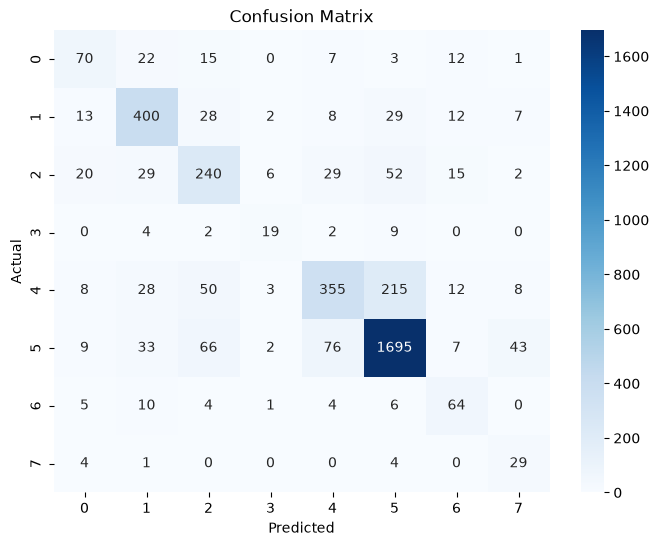

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### ROC-AUC

In [45]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
print("ROC-AUC:", auc)


ROC-AUC: 0.939989084583572


### Federated Learning Simulation (FedAvg)

### Create Client Dataset Split

In [46]:
import numpy as np
from torch.utils.data import Subset

NUM_CLIENTS = 4


def split_dataset(dataset, num_clients):
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)

    split_indices = np.array_split(indices, num_clients)

    client_datasets = []

    for idx in split_indices:
        client_datasets.append(Subset(dataset, idx))

    return client_datasets


client_datasets = split_dataset(train_dataset, NUM_CLIENTS)

for i, dataset in enumerate(client_datasets):
    print(f"Client {i+1}: {len(dataset)} samples")


Client 1: 18024 samples
Client 2: 18024 samples
Client 3: 18024 samples
Client 4: 18024 samples


### Client DataLoader

In [47]:
from torch.utils.data import DataLoader

client_loaders = []

for dataset in client_datasets:
    loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
    client_loaders.append(loader)

print("Client DataLoaders created:", len(client_loaders))


Client DataLoaders created: 4


### Check Client Data

In [48]:
for i, loader in enumerate(client_loaders):
    images, labels = next(iter(loader))
    print("Client", i + 1, images.shape, labels.shape)


Client 1 torch.Size([4, 3, 224, 224]) torch.Size([4])
Client 2 torch.Size([4, 3, 224, 224]) torch.Size([4])
Client 3 torch.Size([4, 3, 224, 224]) torch.Size([4])
Client 4 torch.Size([4, 3, 224, 224]) torch.Size([4])


In [49]:
import sys
import os

sys.path.append("./federated")

from client import ISICClient
from server import get_strategy

print("Flower modules loaded")

Flower modules loaded


In [50]:
import copy
import torch

# Use trained global model
fl_global_model = copy.deepcopy(best_model).to(device)
print("Federated global model ready")


Federated global model ready


In [52]:
def client_fn(cid):
    client_model = copy.deepcopy(fl_global_model)
    client_model = client_model.to(device)

    return ISICClient(
        client_model,
        client_loaders[int(cid)],
        device,
        combined_loss,
        get_binary_label
    ).to_client()

In [53]:
# Test client creation

test_client = client_fn("0")
print(type(test_client))
print("Client created successfully")

<class 'abc.NumPyClientWrapper'>
Client created successfully


In [54]:
# Get FedAvg strategy

strategy = get_strategy()
print("FedAvg strategy ready")

FedAvg strategy ready


In [55]:
import sys

print(sys.executable)

c:\Users\Student\.conda\envs\gpu_env\python.exe


In [58]:
import sys
import socket
import subprocess
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED

import grpc
import flwr as fl


def run_local_federation():
    project_dir = Path(PROJECT_PATH).resolve()
    server_script = project_dir / "federated" / "server.py"
    log_path = project_dir / "federated_server.log"
    address = "127.0.0.1:8080"

    if not server_script.is_file():
        raise FileNotFoundError(
            f"Server file not found: {server_script}"
        )

    if NUM_CLIENTS != 4 or len(client_loaders) != 4:
        raise ValueError(
            "The current server requires exactly four clients."
        )

    # Check whether another server is already using this port.
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
        probe.settimeout(1)

        if probe.connect_ex(("127.0.0.1", 8080)) == 0:
            raise RuntimeError(
                "Port 8080 is already in use. Stop the previous "
                "server before running this cell."
            )

    server_process = None
    pool = None

    try:
        with log_path.open("w", encoding="utf-8") as server_log:

            # Start server using the notebook's Python environment.
            server_process = subprocess.Popen(
                [sys.executable, "-u", str(server_script)],
                cwd=str(project_dir),
                stdout=server_log,
                stderr=subprocess.STDOUT,
            )

            print(
                f"Starting server. Log: {log_path}",
                flush=True,
            )

            # Wait until the server accepts a gRPC connection.
            with grpc.insecure_channel(address) as channel:
                ready = grpc.channel_ready_future(channel)
                deadline = time.monotonic() + 60

                while True:
                    if server_process.poll() is not None:
                        raise RuntimeError(
                            f"Server exited during startup. Read {log_path}"
                        )

                    try:
                        ready.result(timeout=1)
                        break

                    except grpc.FutureTimeoutError:
                        if time.monotonic() >= deadline:
                            raise TimeoutError(
                                "Server was not ready within 60 seconds. "
                                f"Read {log_path}"
                            )

            print(
                f"Server ready at {address}. Starting four clients.",
                flush=True,
            )

            def connect_client(cid):
                print(f"Starting client {cid}", flush=True)

                fl.client.start_client(
                    server_address=address,
                    client=client_fn(str(cid)),
                )

            # Connect all four clients.
            pool = ThreadPoolExecutor(max_workers=NUM_CLIENTS)

            futures = {
                pool.submit(connect_client, cid): cid
                for cid in range(NUM_CLIENTS)
            }

            pending = set(futures)

            while pending:
                done, pending = wait(
                    pending,
                    timeout=1,
                    return_when=FIRST_COMPLETED,
                )

                for future in done:
                    try:
                        future.result()

                    except BaseException as exc:
                        raise RuntimeError(
                            f"Client {futures[future]} failed. "
                            f"Read its error and {log_path}"
                        ) from exc

                if server_process.poll() not in (None, 0):
                    raise RuntimeError(
                        f"Server failed. Read {log_path}"
                    )

            return_code = server_process.wait(timeout=30)

            if return_code != 0:
                raise RuntimeError(
                    f"Server exited with code {return_code}. "
                    f"Read {log_path}"
                )

            print(
                "Server and all four clients finished normally. "
                f"Round details: {log_path}"
            )

    finally:
        # Clean up the server started by this cell.
        if server_process is not None and server_process.poll() is None:
            server_process.terminate()

            try:
                server_process.wait(timeout=10)

            except subprocess.TimeoutExpired:
                server_process.kill()
                server_process.wait(timeout=10)

        if pool is not None:
            pool.shutdown(wait=False, cancel_futures=True)


run_local_federation()

Starting server. Log: C:\SRS(ISIC_2019)\federated_server.log
Server ready at 127.0.0.1:8080. Starting four clients.
Starting client 0
Starting client 1
Starting client 2
Starting client 3


	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      
INFO :      Received: get_parameters message 7f4466c0-4eaa-4706-85ac-8d23f2f7744e
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view al

Server and all four clients finished normally. Round details: C:\SRS(ISIC_2019)\federated_server.log


In [59]:
import copy
import json
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
)

checkpoint_root = Path(PROJECT_PATH) / "fl_checkpoints"
manifest_path = checkpoint_root / "latest_run.json"

if not manifest_path.is_file():
    raise FileNotFoundError(
        "No saved FL run found. Run the updated server/client cell first."
    )

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

run_dir = Path(manifest["run_dir"])
final_round = manifest["num_rounds"]
weights_path = run_dir / f"round_{final_round}.npz"

if not weights_path.is_file():
    raise FileNotFoundError(
        f"Final checkpoint is missing: {weights_path}. "
        "Check whether all five rounds finished successfully."
    )

# Reuse the existing model architecture.
final_fl_model = copy.deepcopy(best_model).cpu()
reference_state = final_fl_model.state_dict()
loaded_state = {}

with np.load(weights_path, allow_pickle=False) as saved:
    expected_keys = [f"param_{i:05d}" for i in range(len(reference_state))]

    if set(saved.files) != set(expected_keys):
        raise ValueError("Checkpoint parameter count does not match the model.")

    for i, (name, reference) in enumerate(reference_state.items()):
        array = saved[f"param_{i:05d}"]

        if tuple(array.shape) != tuple(reference.shape):
            raise ValueError(
                f"Shape mismatch for {name}: "
                f"{array.shape} versus {tuple(reference.shape)}"
            )

        loaded_state[name] = torch.tensor(
            array,
            dtype=reference.dtype,
        )

final_fl_model.load_state_dict(loaded_state, strict=True)

# Save the actual aggregated global model.
model_path = run_dir / "final_federated_model.pth"
torch.save(final_fl_model.state_dict(), model_path)

print("Final global model saved:", model_path)

final_fl_model = final_fl_model.to(device)
final_fl_model.eval()

# Use the existing prediction function from your notebook.
fl_y_true, fl_y_pred, fl_y_prob = predict(
    final_fl_model,
    test_loader,
    device,
)

class_names = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC",
]

print("\nFEDERATED MODEL TEST RESULTS")
print(f"Accuracy: {accuracy_score(fl_y_true, fl_y_pred):.4f}")
print(
    f"Macro F1: {f1_score(fl_y_true, fl_y_pred, average='macro', zero_division=0):.4f}"
)
print(
    f"Weighted F1: {f1_score(fl_y_true, fl_y_pred, average='weighted', zero_division=0):.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        fl_y_true,
        fl_y_pred,
        labels=list(range(8)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

if len(np.unique(fl_y_true)) == 8:
    auc = roc_auc_score(
        fl_y_true,
        fl_y_prob,
        multi_class="ovr",
        average="macro",
    )
    print(f"Macro ROC-AUC: {auc:.4f}")
else:
    print("ROC-AUC skipped: some classes are absent from the test set.")


Final global model saved: C:\SRS(ISIC_2019)\fl_checkpoints\215894530a8b47e38f99b5e13ee14ab3\final_federated_model.pth

FEDERATED MODEL TEST RESULTS
Accuracy: 0.7934
Macro F1: 0.7224
Weighted F1: 0.7908

Classification Report:
              precision    recall  f1-score   support

          AK     0.5247    0.6538    0.5822       130
         BCC     0.8224    0.8537    0.8378       499
         BKL     0.6832    0.6310    0.6561       393
          DF     0.9286    0.7222    0.8125        36
         MEL     0.7264    0.5788    0.6443       679
          NV     0.8601    0.9011    0.8801      1931
         SCC     0.5245    0.7979    0.6329        94
        VASC     1.0000    0.5789    0.7333        38

    accuracy                         0.7934      3800
   macro avg     0.7587    0.7147    0.7224      3800
weighted avg     0.7952    0.7934    0.7908      3800

Macro ROC-AUC: 0.9467
